## Stock prediction using LSTM

In [14]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Load Dataset
df = pd.read_csv('AAPL_stock_2015_2025.csv', skiprows=[1])
data = df['Close'].values.reshape(-1,1)


In [15]:
# Normalize Data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# Create Training Data
X_train = []
y_train = []

for i in range(60, len(scaled_data)):
    X_train.append(scaled_data[i-60:i, 0])
    y_train.append(scaled_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

# Reshape for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Build Model
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=1))

# Compile Model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train Model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Prediction
test_data = scaled_data[-60:]
test_data = np.reshape(test_data, (1, test_data.shape[0], 1))

predicted_price = model.predict(test_data)
predicted_price = scaler.inverse_transform(predicted_price)

print("Predicted Stock Price:", predicted_price)

Epoch 1/10


C:\Users\heyysam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0146
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0023
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0019
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0018
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0015
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0015
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0016
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0015
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0013
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0014
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
Predicted Stock Price: [[257.8827]]


In [ ]:
# Create Test Data
X_test = []
y_test = []

for i in range(60, len(scaled_data)):
    X_test.append(scaled_data[i-60:i, 0])   
    y_test.append(scaled_data[i, 0])

X_test, y_test = np.array(X_test), np.array(y_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Make Predictions
y_pred = model.predict(X_test, verbose=0)
y_pred = y_pred.reshape(-1)

# Evaluate Model
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

y_true = y_test
mae = mean_absolute_error(y_true, y_pred)
rmse = math.sqrt(mean_squared_error(y_true, y_pred))

print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")

Mean Absolute Error: 0.01633865730290956
Root Mean Squared Error: 0.023854187083288757


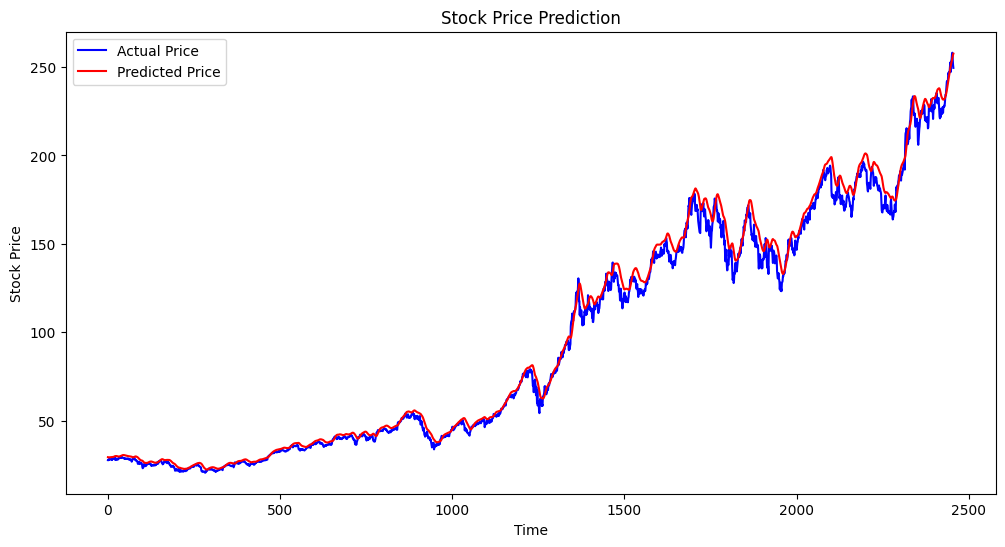

In [20]:
# Inverse Transform Predictions
real_prices = scaler.inverse_transform(y_test.reshape(-1, 1))
predicted_prices = scaler.inverse_transform(y_pred.reshape(-1, 1))

# Plot Results
plt.figure(figsize=(12, 6))
plt.plot(real_prices, color='blue', label='Actual Price')
plt.plot(predicted_prices, color='red', label='Predicted Price')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()